# Task 6: House Price Prediction

## Problem Statement
Predict house prices using property features such as size, number of bedrooms, and location.

This notebook covers:
1. Data loading
2. Data preprocessing
3. Regression model training (Linear Regression and Gradient Boosting)
4. Predicted vs actual visualizations
5. Performance evaluation using MAE and RMSE

## 1) Imports

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

## 2) Load Dataset

Download the Kaggle House Price dataset and place the CSV in this folder, then update `DATA_PATH` if needed.

In [12]:
# Update this path if your CSV file has a different name or location
DATA_PATH = "Housing.csv"

if not os.path.exists(DATA_PATH):
    fallback = "house_price_prediction.csv"
    if os.path.exists(fallback):
        DATA_PATH = fallback
    else:
        raise FileNotFoundError(
            f"Dataset not found at '{DATA_PATH}' or fallback '{fallback}'. Place the CSV in the notebook folder or update DATA_PATH."
        )

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
df.head()

Loaded dataset: Housing.csv
Dataset shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3) Quick Data Check

In [13]:
display(df.info())
display(df.describe(include="all").T.head(20))
display(df.isna().sum().sort_values(ascending=False).head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,545.0,NaN,NaN,NaN,4766729.247706,1870439.615657,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,NaN,NaN,NaN,5150.541284,2170.141023,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,NaN,NaN,NaN,2.965138,0.738064,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,NaN,NaN,NaN,1.286239,0.50247,1.0,1.0,1.0,2.0,4.0
stories,545.0,NaN,NaN,NaN,1.805505,0.867492,1.0,1.0,2.0,2.0,4.0
mainroad,545,2,yes,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guestroom,545,2,no,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basement,545,2,no,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotwaterheating,545,2,no,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airconditioning,545,2,no,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## 4) Define Target and Features

The code below auto-detects a common price target column (e.g., `SalePrice`, `price`, `Price`).
Then it prioritizes feature columns related to square footage, bedrooms, and location when available.

In [14]:
# Common target candidates in house-price datasets
target_candidates = ["SalePrice", "sale_price", "price", "Price", "target"]
target_col = next((c for c in target_candidates if c in df.columns), None)

if target_col is None:
    raise ValueError(
        f"Could not auto-detect target column. Expected one of: {target_candidates}."
    )

# Priority feature candidates tied to task requirements
priority_features = [
    "sqft", "square_feet", "square footage", "GrLivArea", "LotArea",
    "bedrooms", "BedroomAbvGr", "BHK",
    "location", "Location", "Neighborhood", "city"
]

# Case-insensitive matching for priority features
col_map_lower = {c.lower(): c for c in df.columns}
selected_priority = []
for f in priority_features:
    key = f.lower()
    if key in col_map_lower and col_map_lower[key] != target_col:
        selected_priority.append(col_map_lower[key])

# If few priority columns exist, include additional useful columns
if len(selected_priority) < 3:
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    if target_col in numeric_cols:
        numeric_cols.remove(target_col)

    selected_features = numeric_cols + categorical_cols
else:
    selected_features = selected_priority

X = df[selected_features].copy()
y = df[target_col].copy()

print(f"Target column: {target_col}")
print(f"Number of selected features: {len(selected_features)}")
print("Selected features (first 20):", selected_features[:20])

Target column: price
Number of selected features: 12
Selected features (first 20): ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


## 5) Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (436, 12), Test shape: (109, 12)


## 6) Preprocessing Pipeline

- Numeric features: median imputation + standardization
- Categorical features: most-frequent imputation + one-hot encoding

In [16]:
num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features),
])

print(f"Numeric features: {len(num_features)}")
print(f"Categorical features: {len(cat_features)}")

Numeric features: 5
Categorical features: 7


## 7) Model Training (Linear Regression + Gradient Boosting)

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
predictions = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    # Version-agnostic RMSE (works across sklearn versions)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({"Model": model_name, "MAE": mae, "RMSE": rmse})
    predictions[model_name] = (pipe, y_pred)

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

,Model,MAE,RMSE
1,Gradient Boosting,969687.92658,1.302053e+06
0,Linear Regression,970043.40392,1.324507e+06


## 8) Visualization: Predicted vs Actual

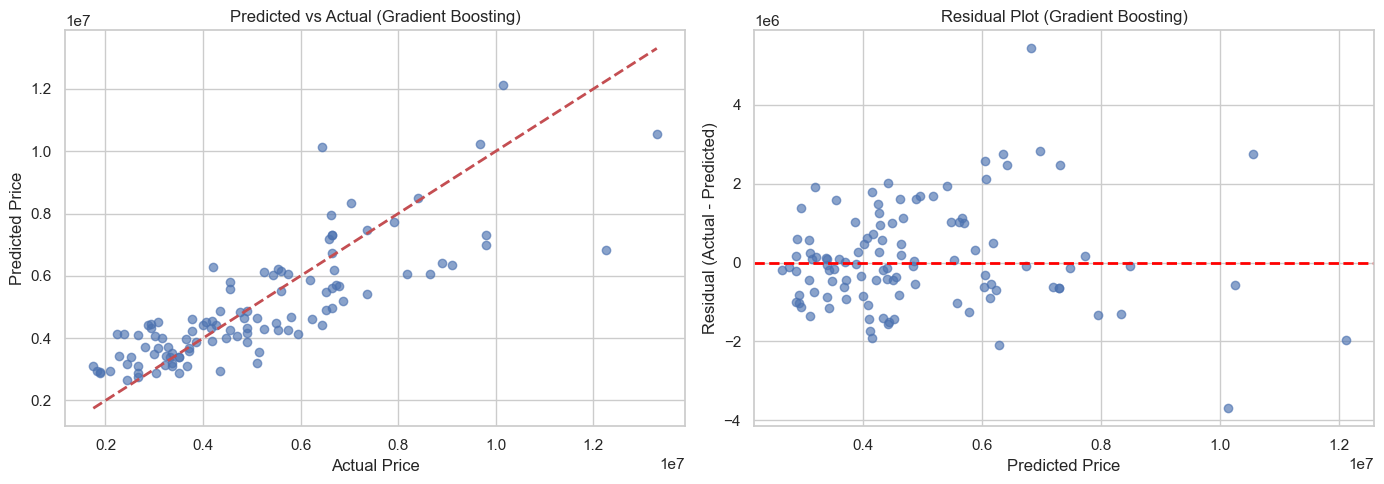

In [18]:
best_model_name = results_df.iloc[0]["Model"]
best_model, best_pred = predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: predicted vs actual
axes[0].scatter(y_test, best_pred, alpha=0.65)
line_min = min(y_test.min(), best_pred.min())
line_max = max(y_test.max(), best_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2)
axes[0].set_title(f"Predicted vs Actual ({best_model_name})")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")

# Residual plot
residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.65)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title(f"Residual Plot ({best_model_name})")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

## 9) Model Performance Summary

In [19]:
display(results_df)

print("Best model based on RMSE:", best_model_name)
best_mae = results_df.loc[results_df["Model"] == best_model_name, "MAE"].iloc[0]
best_rmse = results_df.loc[results_df["Model"] == best_model_name, "RMSE"].iloc[0]

print(f"MAE: {best_mae:,.2f}")
print(f"RMSE: {best_rmse:,.2f}")

,Model,MAE,RMSE
1,Gradient Boosting,969687.92658,1.302053e+06
0,Linear Regression,970043.40392,1.324507e+06


Best model based on RMSE: Gradient Boosting
MAE: 969,687.93
RMSE: 1,302,052.72
